# Breast Cancer Tumor Classifier

This notebook covers:
- Exploratory Data Analysis (EDA)
- Feature relationship analysis
- Model training with `RandomForest` and `SVM`
- Hyperparameter tuning with `GridSearchCV`
- Model evaluation and comparison


## 1. Load Data


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

sns.set_theme(style="whitegrid")

cancer_dataest = pd.read_csv('data/data.csv')

print(f"Dataset shape: {cancer_dataest.shape}")
cancer_dataest.head()


Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. Dataset Overview


In [ ]:
cancer_dataest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [18]:
cancer_dataest.describe(include='all')


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN


## 3. Data Cleaning and Target Distribution


Class counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


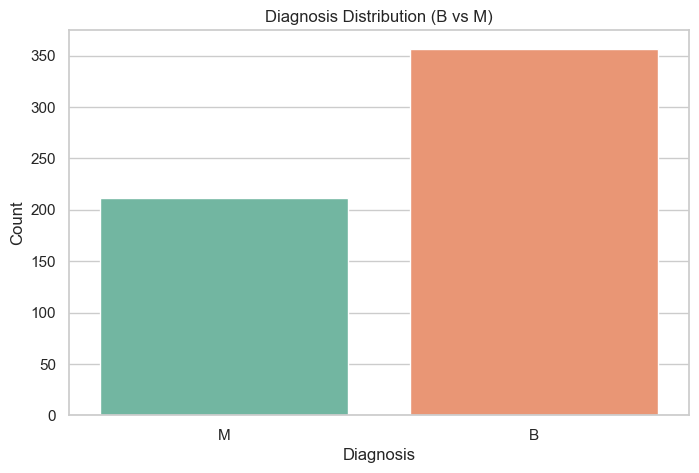

In [19]:
# Remove non-informative columns
cancer_dataest = cancer_dataest.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print("Class counts:")
print(cancer_dataest['diagnosis'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=cancer_dataest, x='diagnosis', hue='diagnosis', palette='Set2', legend=False)
plt.title('Diagnosis Distribution (B vs M)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


## 4. Feature Distributions


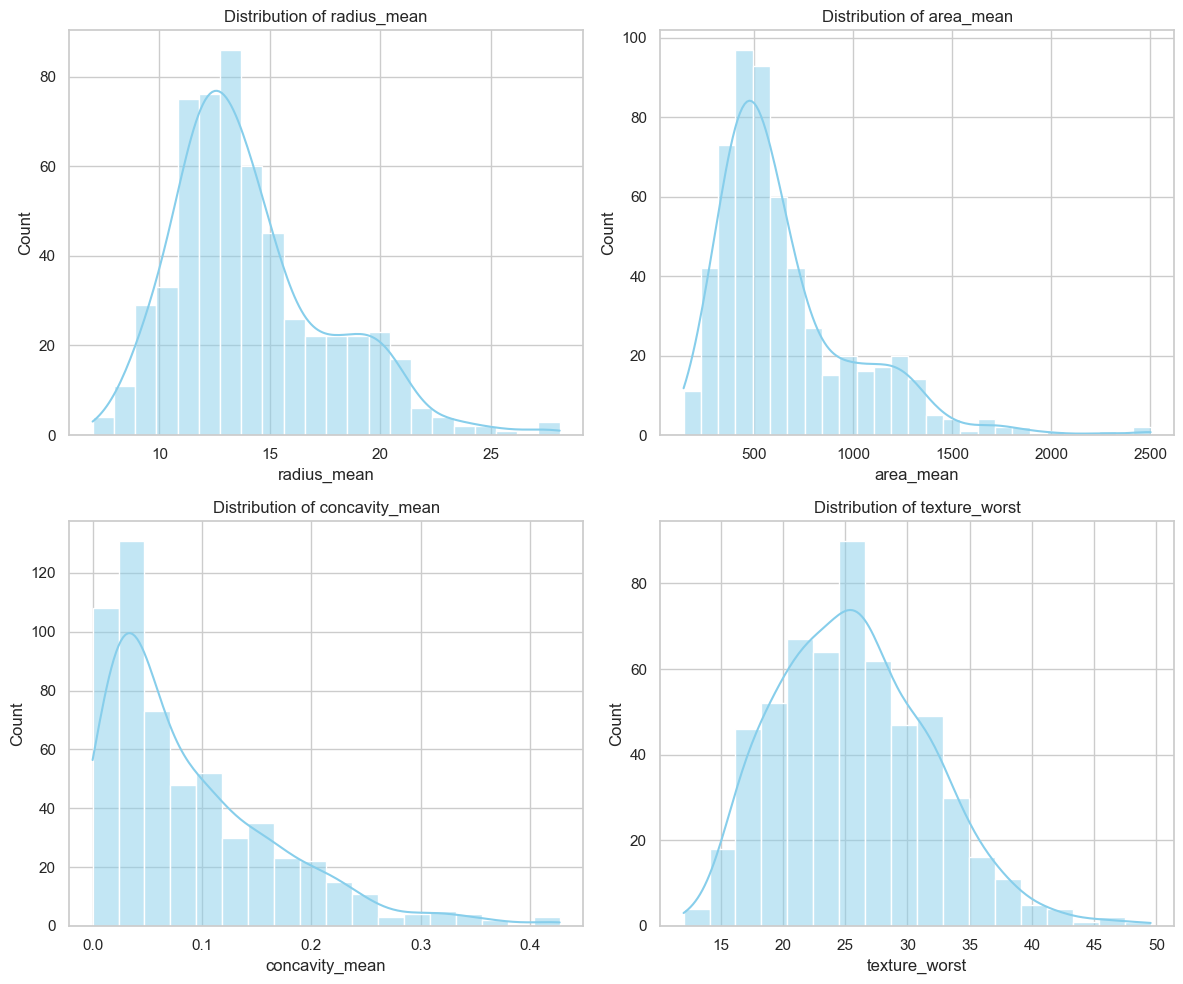

In [20]:
columns = ["radius_mean", "area_mean", "concavity_mean", "texture_worst"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, c in enumerate(columns):
    sns.histplot(cancer_dataest[c], kde=True, color="skyblue", ax=axes[i])
    axes[i].set_title(f"Distribution of {c}")
    axes[i].set_xlabel(c)

plt.tight_layout()
plt.show()


## 5. Boxplots by Diagnosis (All Numeric Features)


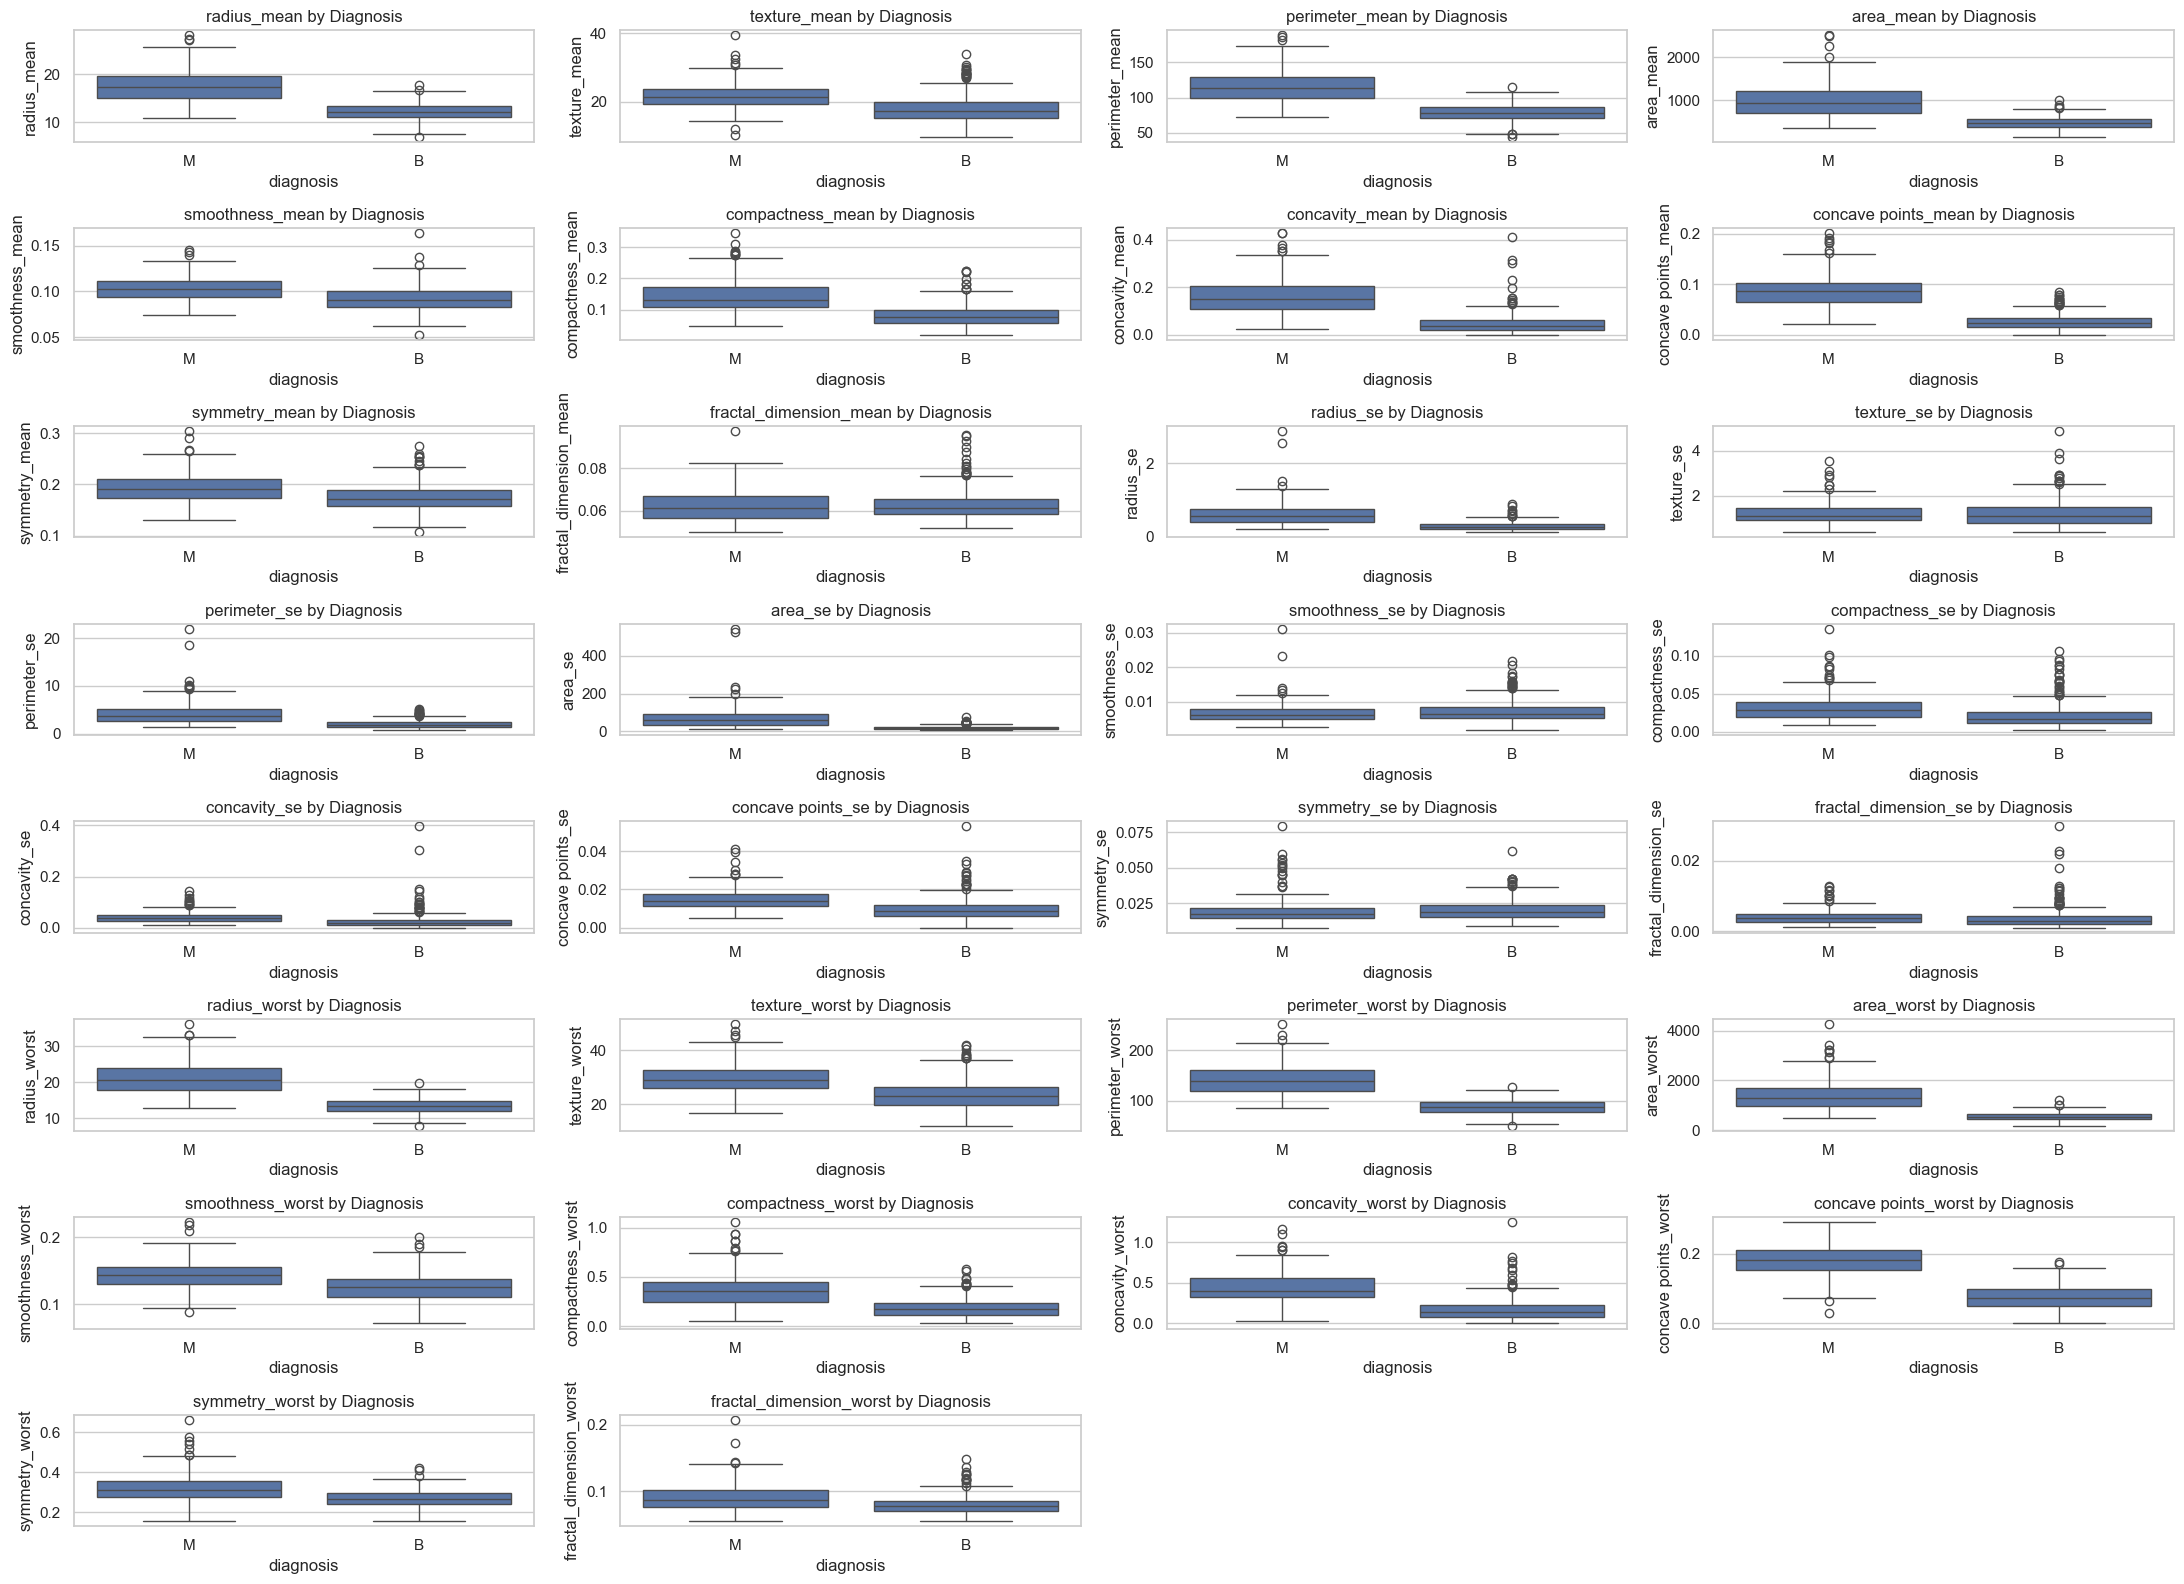

In [21]:
features = [col for col in cancer_dataest.columns if col != 'diagnosis']

fig, axes = plt.subplots(8, 4, figsize=(22, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='diagnosis', y=feature, data=cancer_dataest, ax=axes[i])
    axes[i].set_title(f'{feature} by Diagnosis')

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 6. Top Correlated Features with Diagnosis


Top correlated features with diagnosis:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis_num, dtype: float64


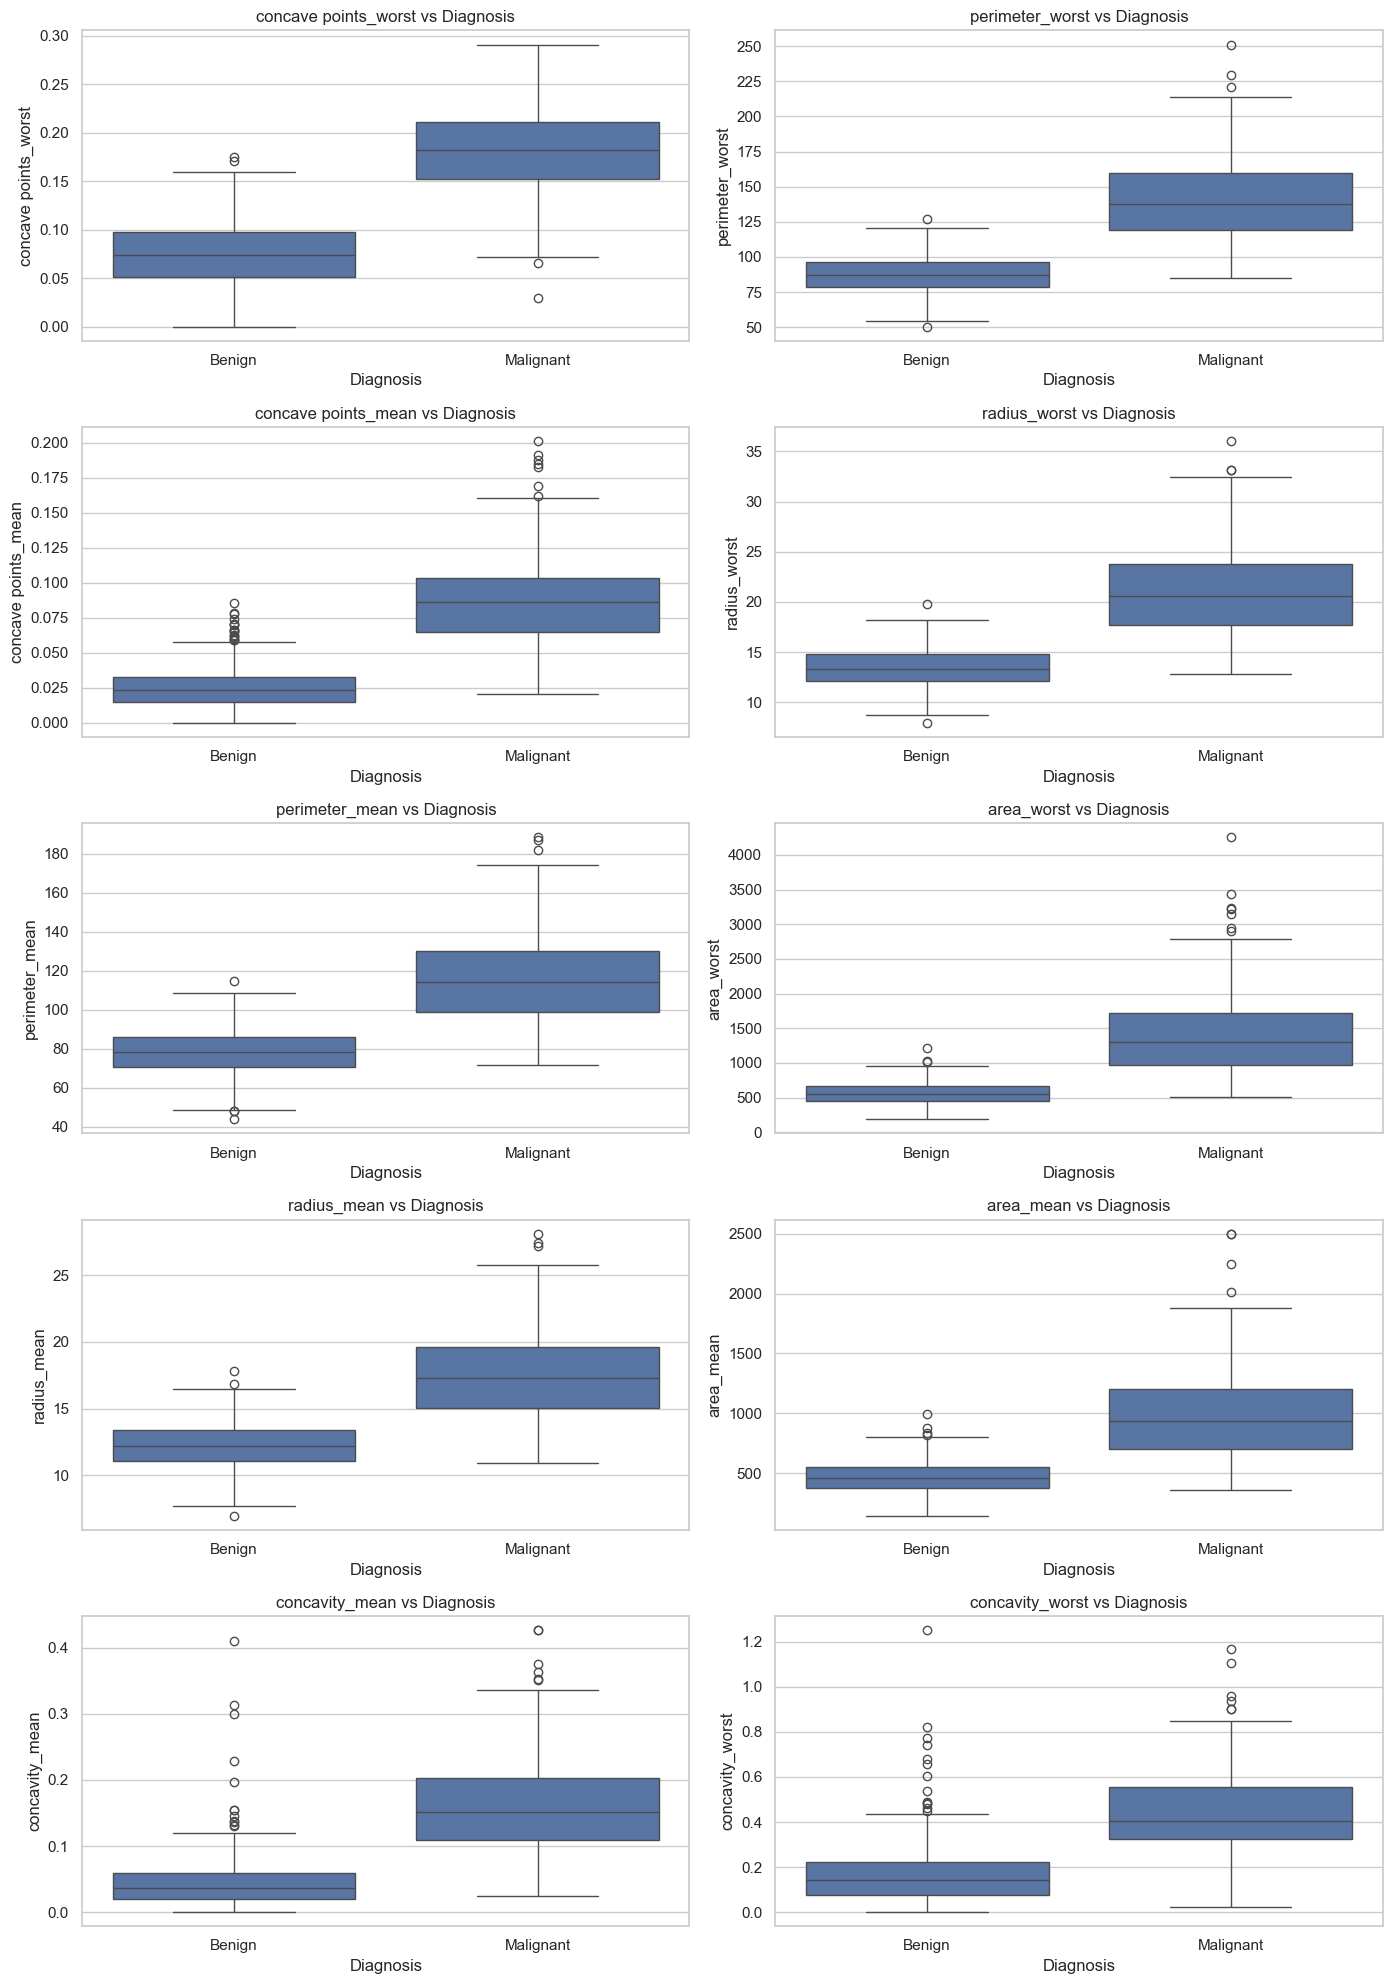

In [22]:
corr_df = cancer_dataest.copy()
corr_df['diagnosis_num'] = corr_df['diagnosis'].map({'B': 0, 'M': 1})

corr_with_target = corr_df.corr(numeric_only=True)['diagnosis_num'].drop('diagnosis_num')

top_n = 10
top_features = corr_with_target.abs().sort_values(ascending=False).head(top_n).index.tolist()

print('Top correlated features with diagnosis:')
print(corr_with_target.abs().sort_values(ascending=False).head(top_n))

plot_df = cancer_dataest.copy()
plot_df['diagnosis'] = plot_df['diagnosis'].map({'B': 'Benign', 'M': 'Malignant'})

fig, axes = plt.subplots(nrows=top_n // 2 + top_n % 2, ncols=2, figsize=(14, 4 * ((top_n // 2) + top_n % 2)))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(
        data=plot_df,
        x='diagnosis',
        y=feature,
        order=['Benign', 'Malignant'],
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} vs Diagnosis')
    axes[i].set_xlabel('Diagnosis')
    axes[i].set_ylabel(feature)

for j in range(len(top_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 7. Correlation Heatmap (Top Features)


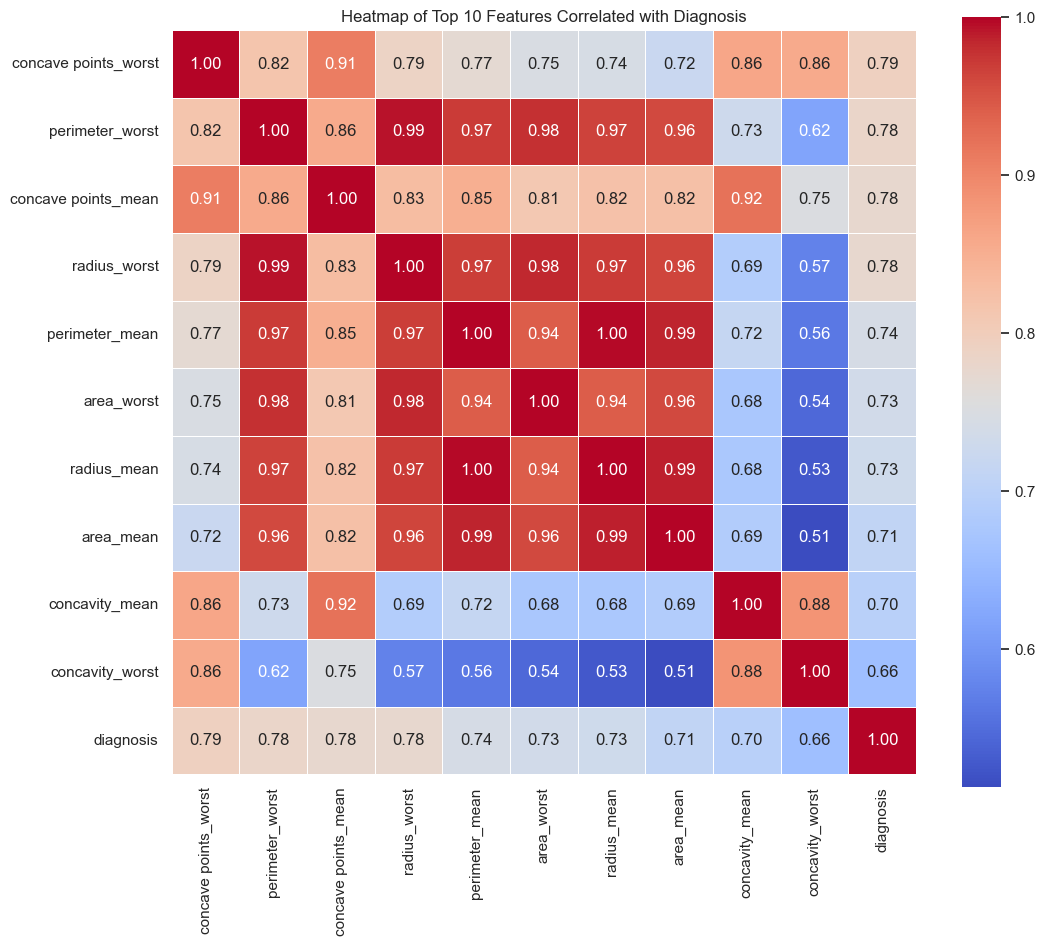

In [23]:
heatmap_df = corr_df[top_features + ['diagnosis_num']].rename(columns={'diagnosis_num': 'diagnosis'})

plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title(f'Heatmap of Top {top_n} Features Correlated with Diagnosis')
plt.show()


## 8. Pairplot of Strongest Features

Using the top 6 strongest features makes the plot easier to read and faster to run.


Pairplot features: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst']


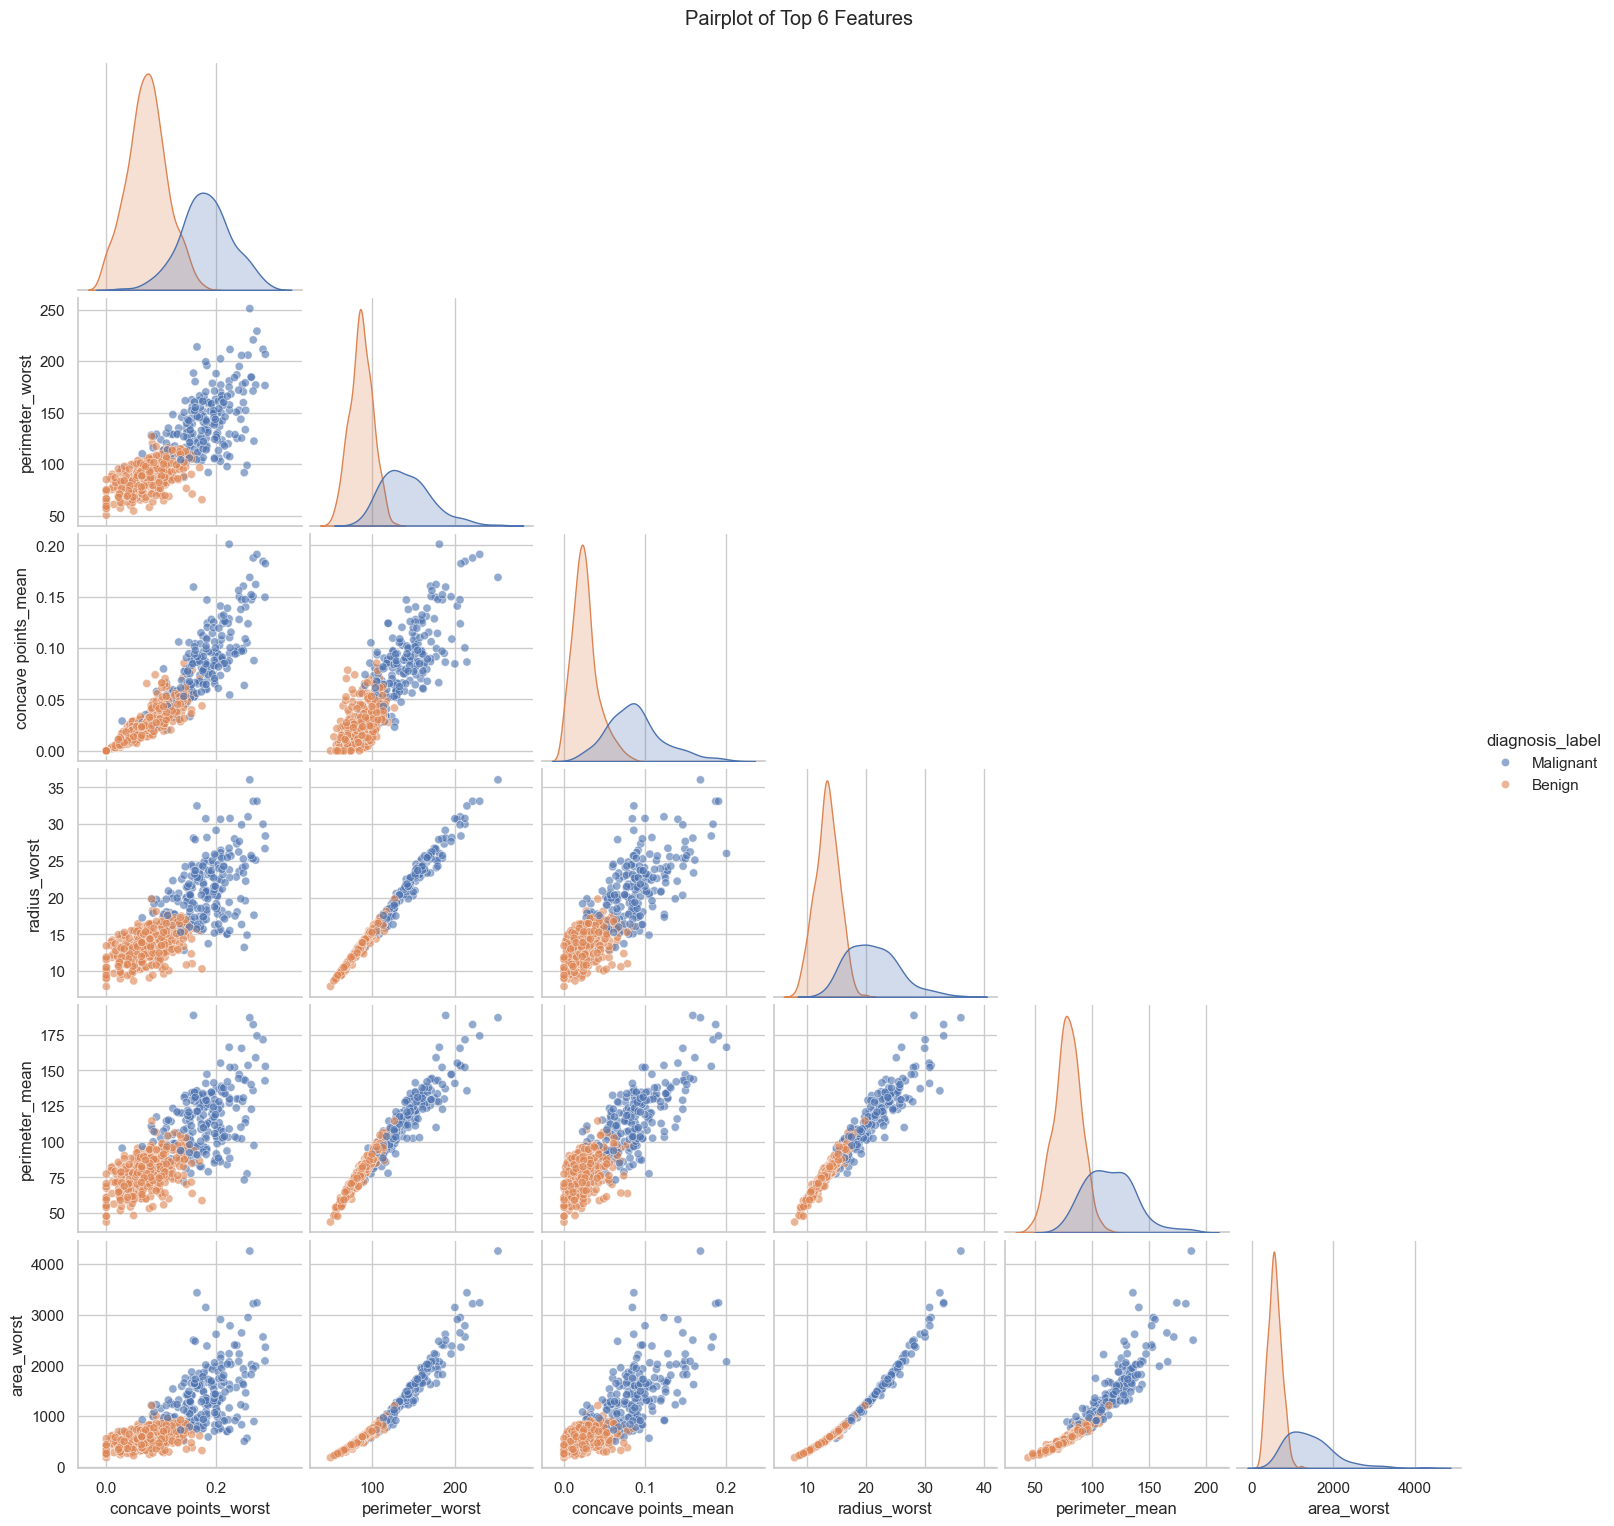

In [24]:
pairplot_top_n = 6
pairplot_features = corr_with_target.abs().sort_values(ascending=False).head(pairplot_top_n).index.tolist()

df_pair = cancer_dataest.copy()
df_pair['diagnosis_label'] = df_pair['diagnosis'].map({'B': 'Benign', 'M': 'Malignant'})

print('Pairplot features:', pairplot_features)

sns.pairplot(
    df_pair[pairplot_features + ['diagnosis_label']],
    hue='diagnosis_label',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 35}
)

plt.suptitle(f'Pairplot of Top {pairplot_top_n} Features', y=1.02)
plt.show()


## 9. Data Quality Checks


In [25]:
missing_values = cancer_dataest.isnull().sum().sum()
duplicates = cancer_dataest.duplicated().sum()

print(f'Total missing values: {missing_values}')
print(f'Total duplicated rows: {duplicates}')


Total missing values: 0
Total duplicated rows: 0


## 10. Train/Test Split and Model Setup


In [26]:
# Encode target for modeling
df_model = cancer_dataest.copy()
df_model['diagnosis'] = df_model['diagnosis'].map({'B': 0, 'M': 1})

X = df_model.drop(columns='diagnosis')
y = df_model['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (455, 30)
Test shape: (114, 30)


## 11. Random Forest - Grid Search


In [27]:
rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print('Best RF params:', rf_grid.best_params_)
print('Best RF CV score:', rf_grid.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


Best RF params: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 200}
Best RF CV score: 0.9502405343402511


## 12. Random Forest Evaluation


Random Forest Test Accuracy: 0.9649122807017544
Random Forest Test F1: 0.9523809523809523
Random Forest Classification Report:               precision    recall  f1-score   support

           0       0.97      0.97      0.97        72
           1       0.95      0.95      0.95        42

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



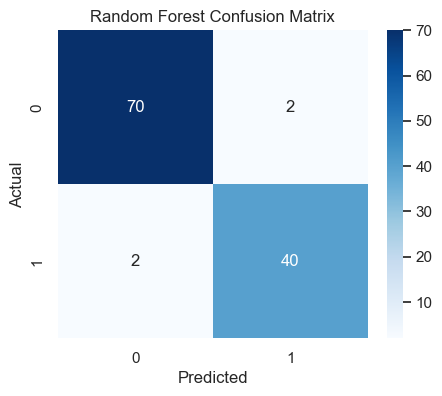

In [28]:
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

print('Random Forest Test Accuracy:', accuracy_score(y_test, rf_pred))
print('Random Forest Test F1:', f1_score(y_test, rf_pred))
print('Random Forest Classification Report:', classification_report(y_test, rf_pred))

rf_cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 13. SVM - Grid Search (with StandardScaler)


In [29]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

svm_param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print('Best SVM params:', svm_grid.best_params_)
print('Best SVM CV score:', svm_grid.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVM params: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best SVM CV score: 0.9674077771676732


## 14. SVM Evaluation


SVM Test Accuracy: 0.9649122807017544
SVM Test F1: 0.9512195121951219
SVM Classification Report:               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



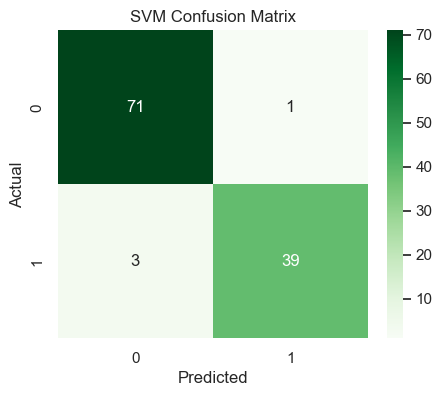

In [30]:
svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test)

print('SVM Test Accuracy:', accuracy_score(y_test, svm_pred))
print('SVM Test F1:', f1_score(y_test, svm_pred))
print('SVM Classification Report:', classification_report(y_test, svm_pred))

svm_cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 15. Final Model Comparison


In [31]:
results = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Best CV F1': rf_grid.best_score_,
        'Test Accuracy': accuracy_score(y_test, rf_pred),
        'Test F1': f1_score(y_test, rf_pred)
    },
    {
        'Model': 'SVM',
        'Best CV F1': svm_grid.best_score_,
        'Test Accuracy': accuracy_score(y_test, svm_pred),
        'Test F1': f1_score(y_test, svm_pred)
    }
])

results.sort_values(by='Test F1', ascending=False)


,Model,Best CV F1,Test Accuracy,Test F1
0,Random Forest,0.950241,0.964912,0.952381
1,SVM,0.967408,0.964912,0.951220
